In [24]:
### 1) Desactivar GPUs y cargar librerías
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay,multilabel_confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.metrics import BinaryAccuracy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Si dispones de una función augment_sequence, la importas aquí
try:
    from library.functions import augment_sequence
except ImportError:
    print("No se encontró augment_sequence, comentar la sección de augmentación si es necesario.")


In [25]:
### 2) Carga de datos
keypoints_data = pd.read_csv(
    'D:/la-u/ciclo 2025-1/Seminario/Proyecto/DATASETS_CSV/keypoints_padded_with_mask.csv'
)
labels_data = pd.read_csv(
    'D:/la-u/ciclo 2025-1/Seminario/Proyecto/DATASETS_CSV/dataset_errores.csv',
    sep=','
)

keypoints_data['video_filename'] = keypoints_data['video_filename'].str.strip()
labels_data['nombre_video']    = labels_data['nombre_video'].str.strip()


In [26]:
### 3) Filtrado de landmarks y preparación de etiquetas
landmarks_to_keep = [23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
print(f"Número de landmarks seleccionados: {len(landmarks_to_keep)}")

# Filtramos solo esos landmarks
keypoints_data = keypoints_data[keypoints_data['landmark_index'].isin(landmarks_to_keep)].reset_index(drop=True)

# Convertir 'lado' a numérico
labels_data['lado'] = labels_data['lado'].map({'I': 0, 'D': 1})

error_cols = [
    'giro_incompleto', 'pierna_patea_flexionada', 'pierna_base_flexionada',
    'pie_sin_borde_externo', 'preparacion_incompleta', 'recogida_incompleta'
]
all_cols = error_cols + ['lado']
labels_dict = labels_data.set_index('nombre_video')[all_cols].to_dict(orient='index')


Número de landmarks seleccionados: 10


In [27]:
### 4) Reconstrucción de secuencias por video
video_frames = {}

def angle(a, b, c):
    ba = a - b
    bc = c - b
    cos = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))
landmarks = landmarks_to_keep

for (video, frame), group in keypoints_data.groupby(['video_filename', 'frame']):
    group_sorted = group.sort_values(by='landmark_index')
    # frame_vector = group_sorted[['x', 'y', 'z', 'visibility']].values.flatten()
    pts = group_sorted[['x', 'y', 'z']].values
    vis = group_sorted['visibility'].values[:,None]
    frame_vec = np.hstack([pts, vis]).flatten()

    # Calcular ángulos entre landmarks específicos (cadera, rodilla, tobillo)
    idx = {lm:i for i, lm in enumerate(landmarks)}
    L_HIP, R_HIP = pts[idx[23]], pts[idx[24]]
    L_KNEE, R_KNEE = pts[idx[25]], pts[idx[26]]
    L_ANK,  R_ANK  = pts[idx[27]], pts[idx[28]]
    L_HEEL, R_HEEL = pts[idx[29]], pts[idx[30]]
    L_FI,   R_FI   = pts[idx[31]], pts[idx[32]]

    ang_knee_L  = angle(L_HIP,  L_KNEE, L_ANK)
    ang_knee_R  = angle(R_HIP,  R_KNEE, R_ANK)
    ang_ankle_L = angle(L_KNEE, L_ANK,  L_HEEL)
    ang_ankle_R = angle(R_KNEE, R_ANK,  R_HEEL)

    #Vectores direccióndel pie:

    dir_foot_L = (L_FI - L_HEEL)/(np.linalg.norm(L_FI - L_HEEL) + 1e-8)
    dir_foot_R = (R_FI - R_HEEL)/(np.linalg.norm(R_FI - R_HEEL) + 1e-8)

    extras = np.hstack([
        [ang_knee_L, ang_knee_R, ang_ankle_L, ang_ankle_R],
        dir_foot_L, dir_foot_R
    ])

    video_frames.setdefault(video, []).append(np.concatenate([frame_vec, extras]))

fixed_frame_count = max(len(frames) for frames in video_frames.values())
frame_dim = len(landmarks_to_keep) * 4 + 10
print(f"Frames fijos: {fixed_frame_count}, features/frame: {frame_dim}")

X_flat = []
video_names = []
for video, frames in video_frames.items():
    assert len(frames) == fixed_frame_count, f"{video} no tiene {fixed_frame_count} frames"
    X_flat.append(np.array(frames).flatten())
    video_names.append(video)

X_flat = np.array(X_flat)
num_videos = X_flat.shape[0]
print("X_flat.shape:", X_flat.shape)

X = X_flat.reshape((num_videos, fixed_frame_count, frame_dim)).astype('float32')
print("X.shape (3D):", X.shape)


Frames fijos: 162, features/frame: 50
X_flat.shape: (500, 8100)
X.shape (3D): (500, 162, 50)


In [28]:
### 5) Construcción de y (multi-etiqueta)
y_list = []
for video in video_names:
    if video in labels_dict:
        y_list.append([labels_dict[video][col] for col in all_cols])
    else:
        print(f"Etiqueta faltante para {video}, se asume cero.")
        y_list.append([0] * len(all_cols))

y = np.array(y_list).astype('float32')
print("y.shape:", y.shape)


y.shape: (500, 7)


In [29]:
### 6) Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, shuffle=True
)
print("X_train:", X_train.shape, "X_val:", X_val.shape)
print("y_train:", y_train.shape, "y_val:", y_val.shape)


X_train: (425, 162, 50) X_val: (75, 162, 50)
y_train: (425, 7) y_val: (75, 7)


In [30]:
### 7) Escalado preservando padding (Masking)
def scale_preserving_padding(X_split):
    ns, nf, nd = X_split.shape
    X_flat = X_split.reshape(-1, nd)
    zero_rows = np.all(X_flat == 0.0, axis=1)
    scaler = StandardScaler()
    non_zero_idx = np.where(~zero_rows)[0]
    if len(non_zero_idx) == 0:
        return X_split.copy(), zero_rows.reshape(ns, nf), None
    scaler.fit(X_flat[non_zero_idx, :])
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled_flat[zero_rows, :] = 0.0
    X_scaled = X_scaled_flat.reshape(ns, nf, nd).astype('float32')
    return X_scaled, zero_rows.reshape(ns, nf), scaler

X_train_scaled, mask_train, scaler = scale_preserving_padding(X_train)
X_val_scaled,   mask_val,   _      = scale_preserving_padding(X_val)
print("mask_train.shape:", mask_train.shape)


mask_train.shape: (425, 162)


In [31]:
### 8) Cálculo de pos_weight para el loss ponderado
pos_counts = np.sum(y_train, axis=0)
neg_counts = y_train.shape[0] - pos_counts
pos_weight = np.zeros_like(pos_counts, dtype='float32')
for i in range(len(pos_counts)):
    if pos_counts[i] == 0:
        pos_weight[i] = 1.0
    else:
        pos_weight[i] = neg_counts[i] / pos_counts[i]
print("pos_weight por etiqueta:", dict(zip(all_cols, pos_weight)))

# Tensor con pesos para usar en la función de pérdida
pos_weight_tensor = tf.constant(pos_weight, shape=(1, len(all_cols)), dtype=tf.float32)


pos_weight por etiqueta: {'giro_incompleto': 1.7777778, 'pierna_patea_flexionada': 15.346154, 'pierna_base_flexionada': 15.346154, 'pie_sin_borde_externo': 2.125, 'preparacion_incompleta': 3.3367348, 'recogida_incompleta': 1.9929577, 'lado': 0.9859813}


In [32]:
### 9) Definir pérdida ponderada (Weighted Binary Crossentropy)
import tensorflow.keras.backend as K

def weighted_binary_crossentropy(y_true, y_pred):
    # BCE sin reducción (shape: batch_size, n_labels)
    bce = K.binary_crossentropy(y_true, y_pred)
    # Máscara de pesos: pos_weight si y_true==1, 1.0 si y_true==0
    weights = tf.where(tf.equal(y_true, 1.0), pos_weight_tensor, tf.ones_like(y_true, dtype=tf.float32))
    weighted_bce = bce * weights
    return K.mean(weighted_bce)


In [ ]:
### 10) Definir arquitectura del modelo con mayor regularización
num_frames = fixed_frame_count
num_features = frame_dim
num_labels = y_train.shape[1]

input_seq = Input(shape=(num_frames, num_features), name='input_secuencia')
mask_layer = layers.Masking(mask_value=0.0, name='masking')(input_seq)

x = layers.Bidirectional(
    layers.LSTM(256, return_sequences=True, kernel_regularizer=regularizers.l2(1e-3)),
    name='bidi_lstm_128'
)(mask_layer)
x = layers.Dropout(0.6, name='dropout_1')(x)

x = layers.Bidirectional(
    layers.LSTM(128, return_sequences=True, kernel_regularizer=regularizers.l2(1e-3)),
    name='bidi_lstm_2'
)(x)
x = layers.Dropout(0.5, name='dropout_2')(x)

x = layers.LSTM(64, return_sequences=False, kernel_regularizer=regularizers.l2(1e-3), name='lstm_64')(x)
x = layers.Dropout(0.5, name='dropout_3')(x)

x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-3), name='dense_1')(x)
x = layers.Dropout(0.5, name='dropout_4')(x)

x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-3), name='dense_2')(x)
x = layers.Dropout(0.5, name='dropout_5')(x)

x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-3), name='dense_3')(x)
x = layers.Dropout(0.5, name='dropout_6')(x)

output = layers.Dense(num_labels, activation='sigmoid', name='output')(x)

model = Model(inputs=input_seq, outputs=output, name='modelo_patada_lateral')


In [34]:
### 11) Compilar el modelo con loss ponderado y métricas por etiqueta
metrics_list = ['accuracy']
for label_name in all_cols:
    metrics_list.append(BinaryAccuracy(name=f'acc_{label_name}', dtype=tf.float32))

model.compile(
    optimizer='adam',
    loss=weighted_binary_crossentropy,
    metrics=metrics_list
)
model.summary()


Model: "modelo_patada_lateral"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_secuencia (InputLayer  [(None, 162, 50)]        0         
 )                                                               
                                                                 
 masking (Masking)           (None, 162, 50)           0         
                                                                 
 bidi_lstm_128 (Bidirectiona  (None, 162, 512)         628736    
 l)                                                              
                                                                 
 dropout_1 (Dropout)         (None, 162, 512)          0         
                                                                 
 lstm_64 (LSTM)              (None, 128)               328192    
                                                                 
 dropout_2 (Dropout)         (None, 128)     

In [35]:
### 12) Definir callbacks con ReduceLROnPlateau
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]


In [36]:
# def data_generator_with_augmentation(X, y, batch_size=8, shuffle=True):
#     n_samples = X.shape[0]
#     indices = np.arange(n_samples)
#     while True:
#         if shuffle:
#             np.random.shuffle(indices)
#         for start in range(0, n_samples, batch_size):
#             end = min(start + batch_size, n_samples)
#             batch_idx = indices[start:end]
#             X_batch = X[batch_idx]
#             y_batch = y[batch_idx]
#             X_aug = np.zeros_like(X_batch)
#             for i, seq in enumerate(X_batch):
#                 try:
#                     X_aug[i] = augment_sequence(seq)
#                 except Exception:
#                     X_aug[i] = seq
#             yield (X_aug, y_batch)

# batch_size = 8
# train_gen = data_generator_with_augmentation(X_train_scaled, y_train, batch_size=batch_size)
# steps_per_epoch = int(np.ceil(X_train_scaled.shape[0] / batch_size))

# history = model.fit(
#     train_gen,
#     steps_per_epoch=steps_per_epoch,
#     epochs=150,
#     validation_data=(X_val_scaled, y_val),
#     callbacks=callbacks,
#     verbose=2
# )


history = model.fit(
    X_train_scaled,      # Datos de entrenamiento escalados
    y_train,             # Etiquetas de entrenamiento
    validation_data=(X_val_scaled, y_val),  # Conjunto de validación
    epochs=150,          # Número de épocas
    batch_size=8,        # Tamaño de batch
    callbacks=callbacks, # EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
    verbose=2
)

Epoch 1/150

Epoch 1: val_loss improved from inf to 1.53463, saving model to best_model.h5
54/54 - 35s - loss: 1.8101 - accuracy: 0.2118 - acc_giro_incompleto: 0.6306 - acc_pierna_patea_flexionada: 0.6306 - acc_pierna_base_flexionada: 0.6306 - acc_pie_sin_borde_externo: 0.6306 - acc_preparacion_incompleta: 0.6306 - acc_recogida_incompleta: 0.6306 - acc_lado: 0.6306 - val_loss: 1.5346 - val_accuracy: 0.3067 - val_acc_giro_incompleto: 0.7638 - val_acc_pierna_patea_flexionada: 0.7638 - val_acc_pierna_base_flexionada: 0.7638 - val_acc_pie_sin_borde_externo: 0.7638 - val_acc_preparacion_incompleta: 0.7638 - val_acc_recogida_incompleta: 0.7638 - val_acc_lado: 0.7638 - lr: 0.0010 - 35s/epoch - 652ms/step
Epoch 2/150

Epoch 2: val_loss improved from 1.53463 to 1.36634, saving model to best_model.h5
54/54 - 22s - loss: 1.6259 - accuracy: 0.2824 - acc_giro_incompleto: 0.6770 - acc_pierna_patea_flexionada: 0.6770 - acc_pierna_base_flexionada: 0.6770 - acc_pie_sin_borde_externo: 0.6770 - acc_prepa

In [37]:
### 14) Buscar umbrales óptimos por etiqueta en validación
y_pred_prob = model.predict(X_val_scaled)

best_thresholds = np.zeros(len(all_cols), dtype='float32')
for i, label in enumerate(all_cols):
    y_true_i = y_val[:, i]
    y_scores_i = y_pred_prob[:, i]
    if np.sum(y_true_i) == 0 or np.sum(y_true_i) == len(y_true_i):
        best_thresholds[i] = 0.5
        continue
    best_f1 = 0.0
    best_t = 0.5
    for t in np.linspace(0.1, 0.9, 81):
        y_pred_i = (y_scores_i >= t).astype(int)
        f1 = f1_score(y_true_i, y_pred_i, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresholds[i] = best_t
    print(f"Mejor threshold para '{label}': {best_t:.2f} (F1 = {best_f1:.3f})")

print("Thresholds finales:", dict(zip(all_cols, best_thresholds)))


3/3 [==============================] - 6s 479ms/step
Mejor threshold para 'giro_incompleto': 0.38 (F1 = 0.719)
Mejor threshold para 'pierna_patea_flexionada': 0.89 (F1 = 0.667)
Mejor threshold para 'pierna_base_flexionada': 0.49 (F1 = 0.375)
Mejor threshold para 'pie_sin_borde_externo': 0.50 (F1 = 0.929)
Mejor threshold para 'preparacion_incompleta': 0.67 (F1 = 0.744)
Mejor threshold para 'recogida_incompleta': 0.64 (F1 = 0.880)
Mejor threshold para 'lado': 0.26 (F1 = 1.000)
Thresholds finales: {'giro_incompleto': 0.38, 'pierna_patea_flexionada': 0.89, 'pierna_base_flexionada': 0.49, 'pie_sin_borde_externo': 0.5, 'preparacion_incompleta': 0.67, 'recogida_incompleta': 0.64, 'lado': 0.26}


In [38]:
### 15) Obtener predicción binaria usando thresholds optimizados
y_pred = np.zeros_like(y_pred_prob, dtype='int32')
for i in range(len(all_cols)):
    y_pred[:, i] = (y_pred_prob[:, i] >= best_thresholds[i]).astype(int)

print(classification_report(y_val, y_pred, target_names=all_cols))


                         precision    recall  f1-score   support

        giro_incompleto       0.70      0.74      0.72        31
pierna_patea_flexionada       0.50      1.00      0.67         2
 pierna_base_flexionada       0.25      0.75      0.38         4
  pie_sin_borde_externo       0.96      0.90      0.93        29
 preparacion_incompleta       0.80      0.70      0.74        23
    recogida_incompleta       0.92      0.85      0.88        26
                   lado       1.00      1.00      1.00        46

              micro avg       0.83      0.86      0.84       161
              macro avg       0.73      0.85      0.76       161
           weighted avg       0.87      0.86      0.86       161
            samples avg       0.71      0.71      0.69       161



c:\Users\user\anaconda3\envs\tesis2\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\user\anaconda3\envs\tesis2\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [39]:
from sklearn.metrics import accuracy_score

# Cálculo de accuracy de subconjunto (exact match)
acc = accuracy_score(y_val, y_pred)
print(f"Accuracy (subset accuracy): {acc:.2f}")

# Si prefieres la exactitud “por etiqueta” (TP+TN)/(TP+TN+FP+FN):
from sklearn.metrics import multilabel_confusion_matrix
mcm = multilabel_confusion_matrix(y_val, y_pred)
acc_per_label = [(cm[0,0] + cm[1,1]) / cm.sum() for cm in mcm]
for lbl, acc_lbl in zip(all_cols, acc_per_label):
    print(f"Accuracy {lbl}: {acc_lbl:.2f}")


Accuracy (subset accuracy): 0.55
Accuracy giro_incompleto: 0.76
Accuracy pierna_patea_flexionada: 0.97
Accuracy pierna_base_flexionada: 0.87
Accuracy pie_sin_borde_externo: 0.95
Accuracy preparacion_incompleta: 0.85
Accuracy recogida_incompleta: 0.92
Accuracy lado: 1.00


In [40]:
### 16) Funciones para visualizar métricas y matrices de confusión
def plot_multi_label_confusion(y_true, y_pred, label_names, normalize=False):
    n_labels = len(label_names)
    n_cols = 2
    n_rows = 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    fig.suptitle('Matrices de confusión por etiqueta', fontsize=16, y=0.95)
    for idx, label in enumerate(label_names):
        cm = confusion_matrix(y_true[:, idx], y_pred[:, idx])
        if normalize:
            with np.errstate(all='ignore'):
                cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
                cm = np.nan_to_num(cm)
        im = axes[idx].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        axes[idx].set_title(label)
        axes[idx].set_xticks([0, 1])
        axes[idx].set_yticks([0, 1])
        axes[idx].set_xticklabels(['Negativo', 'Positivo'])
        axes[idx].set_yticklabels(['Negativo', 'Positivo'])
        axes[idx].set_ylabel('Real')
        axes[idx].set_xlabel('Predicho')
        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                val = cm[i, j]
                axes[idx].text(
                    j, i, format(val, fmt),
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black'
                )
    for k in range(n_labels, n_rows * n_cols):
        axes[k].axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.90])
    plt.show()

def plot_per_label_curves(history, label_names):
    n_labels = len(label_names)
    epochs = range(1, len(history.history['loss']) + 1)
    fig, axes = plt.subplots(n_labels, 2, figsize=(12, 3 * n_labels))
    fig.suptitle('Evolución por época: Loss global y Accuracy por etiqueta', fontsize=18, y=0.92)
    for idx, lab in enumerate(label_names):
        ax_loss = axes[idx, 0]
        ax_loss.plot(epochs, history.history['loss'], 'b-', label='train_loss')
        ax_loss.plot(epochs, history.history['val_loss'], 'r--', label='val_loss')
        ax_loss.set_title(f'Loss (global) - Etiqueta: {lab}')
        ax_loss.set_xlabel('Época')
        ax_loss.set_ylabel('CrossEntropy')
        if idx == 0:
            ax_loss.legend()
        key_acc = f'acc_{lab}'
        key_val_acc = f'val_acc_{lab}'
        ax_acc = axes[idx, 1]
        ax_acc.plot(epochs, history.history[key_acc], 'b-', label=f'train_{lab}')
        ax_acc.plot(epochs, history.history[key_val_acc], 'r--', label=f'val_{lab}')
        ax_acc.set_title(f'Accuracy - Etiqueta: {lab}')
        ax_acc.set_xlabel('Época')
        ax_acc.set_ylabel('BinaryAccuracy')
        if idx == 0:
            ax_acc.legend()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


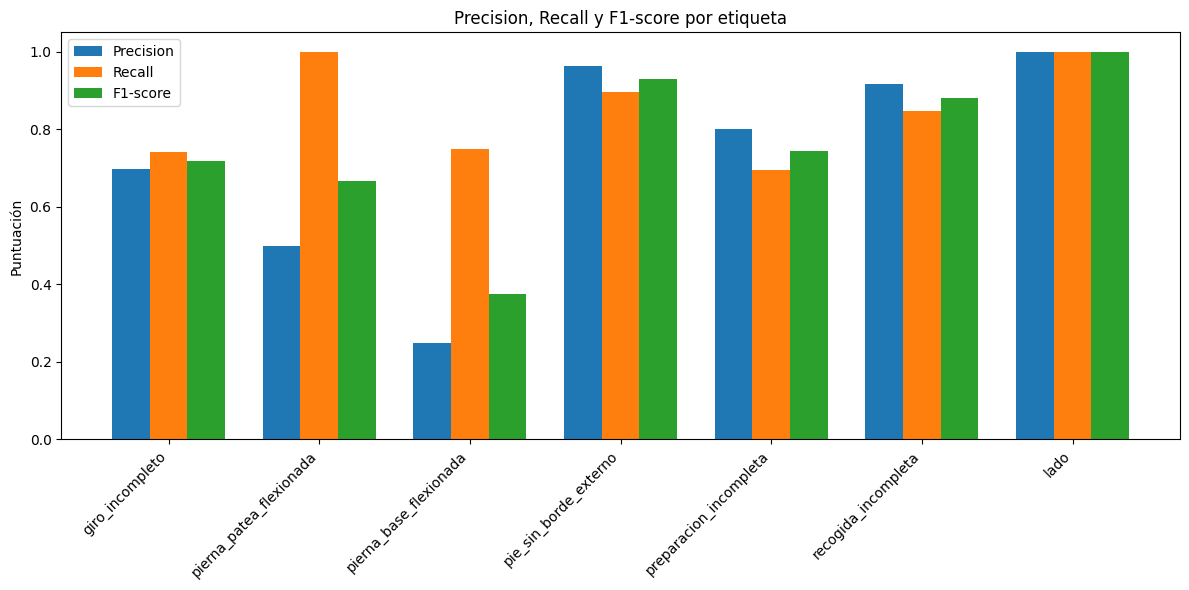

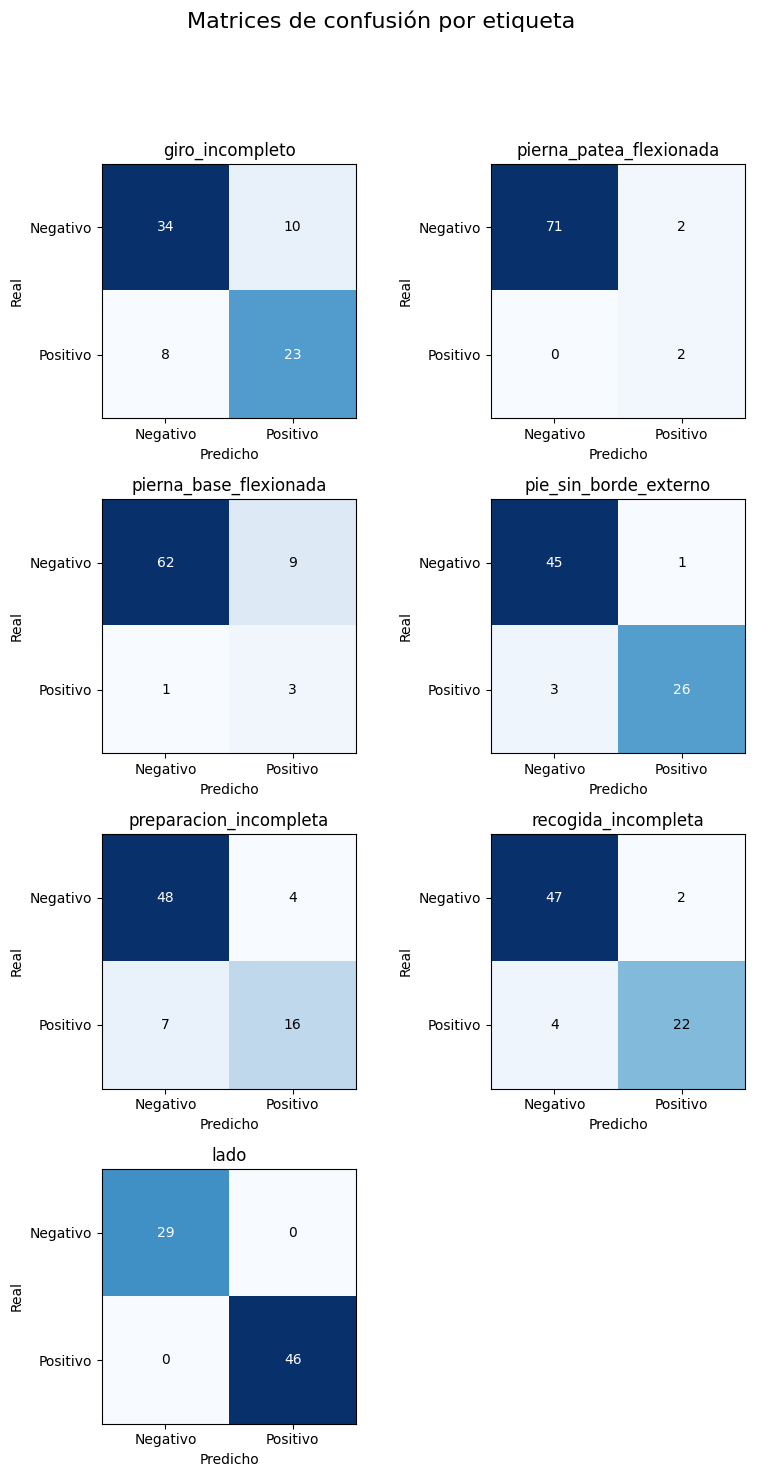

In [41]:
### 17) Mostrar matrices de confusión
# 1) Cálculo de métricas por etiqueta
precisions = precision_score(y_val, y_pred, average=None)
recalls = recall_score(y_val, y_pred, average=None)
f1s = f1_score(y_val, y_pred, average=None)

# 2) Gráfico de barras: precision, recall y f1-score por etiqueta
x = np.arange(len(all_cols))  # posiciones en el eje x para cada etiqueta
width = 0.25  # ancho de cada barra

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, precisions, width, label='Precision')
ax.bar(x, recalls, width, label='Recall')
ax.bar(x + width, f1s, width, label='F1-score')

ax.set_xticks(x)
ax.set_xticklabels(all_cols, rotation=45, ha='right')
ax.set_ylabel('Puntuación')
ax.set_title('Precision, Recall y F1-score por etiqueta')
ax.legend()
plt.tight_layout()
plt.show()
plot_multi_label_confusion(y_val, y_pred, all_cols, normalize=False)


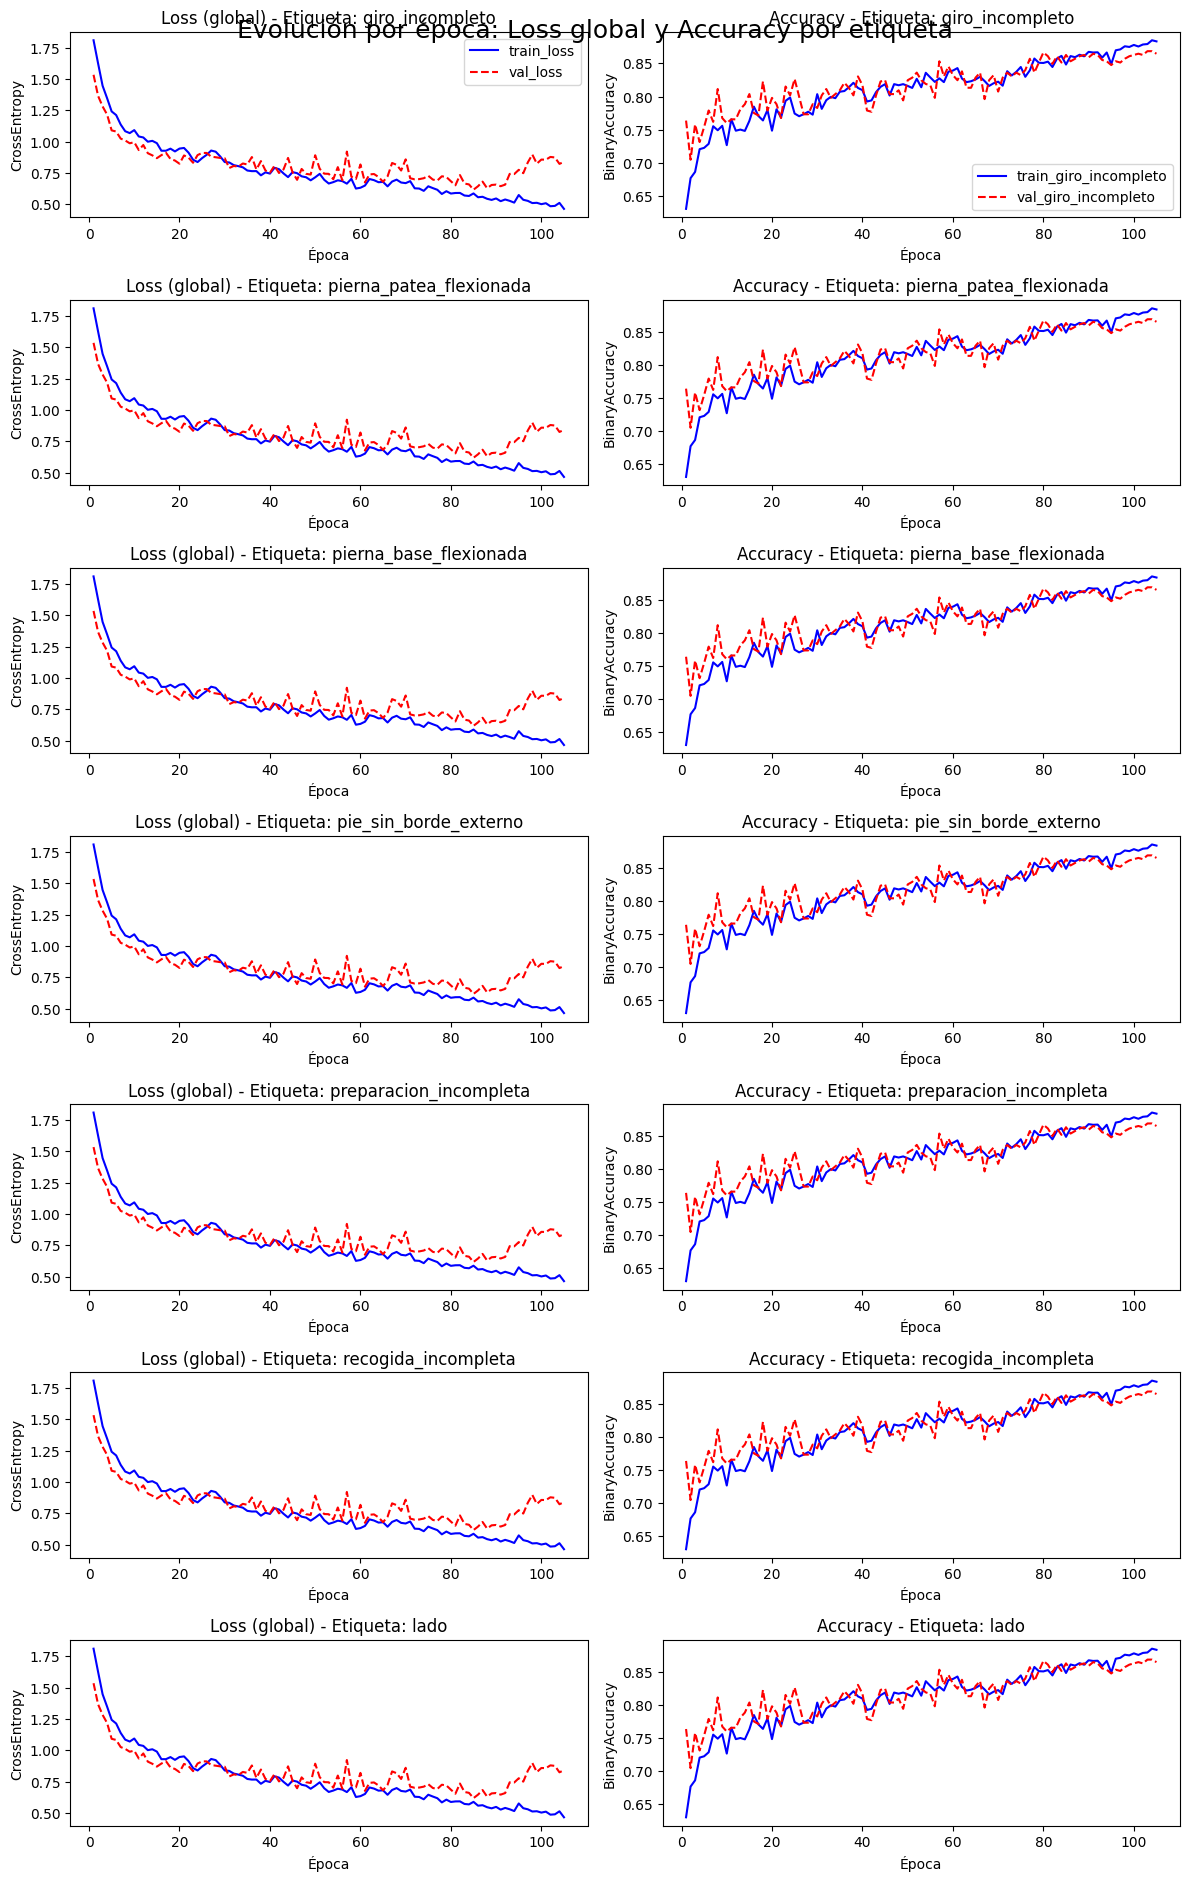

In [42]:
### 18) Mostrar curvas por etiqueta
plot_per_label_curves(history, all_cols)


In [43]:
# # === 16) Cross-Validation con KFold ===
# from sklearn.model_selection import KFold
# from sklearn.metrics import f1_score
# import numpy as np

# # Define aquí la función que construye tu modelo,
# # idéntica a la que usas en la sección 10:
# def build_model_cv(input_shape, num_labels):
#     input_seq = Input(shape=input_shape, name='input_seq_cv')              # --> (None, frames, features)
#     x = layers.Masking(mask_value=0.0, name='masking_cv')(input_seq)      # --> (None, frames, features)
    
#     # por ejemplo usando tu LSTM original:
#     x = layers.Bidirectional(
#         layers.LSTM(128, return_sequences=True, kernel_regularizer=regularizers.l2(1e-3)),
#         name='bidi_lstm_128_cv'
#     )(x)                                                                    # --> (None, frames, 256)
#     x = layers.Dropout(0.6, name='dropout_1_cv')(x)
#     x = layers.LSTM(64, return_sequences=False, kernel_regularizer=regularizers.l2(1e-3), name='lstm_64_cv')(x)
#                                                                           # --> (None, 64)
#     x = layers.Dropout(0.5, name='dropout_2_cv')(x)
    
#     # ya es 2D (batch, 64), perfecto para Dense
#     x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-3), name='dense_64_cv')(x)
#     x = layers.Dropout(0.5, name='dropout_3_cv')(x)
#     x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-3), name='dense_32_cv')(x)
#     x = layers.Dropout(0.5, name='dropout_4_cv')(x)

#     output = layers.Dense(num_labels, activation='sigmoid', name='output_cv')(x)  
#     model = Model(inputs=input_seq, outputs=output, name='modelo_cv')
#     model.compile(
#         optimizer='adam',
#         loss=weighted_binary_crossentropy,
#         metrics=['accuracy'] + [BinaryAccuracy(name=f'acc_{lbl}') for lbl in all_cols]
#     )
#     return model


# # Parámetros de CV
# n_splits = 5
# kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# acc_scores = []
# f1_scores  = []

# for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
#     print(f"\n--- Fold {fold}/5 ---")
#     X_tr, X_val = X[train_idx], X[val_idx]
#     y_tr, y_val = y[train_idx], y[val_idx]

#     X_tr_scaled, _, _ = scale_preserving_padding(X_tr)
#     X_val_scaled, _, _ = scale_preserving_padding(X_val)

#     model_cv = build_model_cv(input_shape=X_tr_scaled.shape[1:], num_labels=y.shape[1])

#     model_cv.fit(
#         X_tr_scaled, y_tr,
#         validation_data=(X_val_scaled, y_val),
#         epochs=150,
#         batch_size=8,
#         callbacks=callbacks,
#         verbose=2
#     )

#     loss, acc = model_cv.evaluate(X_val_scaled, y_val, verbose=0)
#     acc_scores.append(acc)

#     y_pred = (model_cv.predict(X_val_scaled) >= 0.5).astype(int)
#     f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
#     f1_scores.append(f1)

#     print(f"Fold {fold} — Acc: {acc:.4f}, F1: {f1:.4f}")

# print("\n=== CV Results ===")
# print(f"Acc mean: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
# print(f"F1  mean: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
